# Model and state with Flax NNX

Runnable locally on CPU or on a Cloud TPU VM.

- Move the explicit equations into a module
- Separate parameter state from diagnostic state
- Reconstruct an independent graph from a snapshot
- Check a library forward pass independently

A model library can organize weights for us, but we still want to see what is being learned. We’ll build a small Flax NNX module, compare its predictions with NumPy, and inspect its state. A diagnostic counter will help us distinguish trainable parameters from other values a model carries.

## The idea

A model has a computation structure and state values. Some state is trainable; other state may record statistics or randomness. Flax NNX helps manage these objects, but we still need to understand which identities are shared and which values an update changes.

## Distinguish shared structure from changing values

Imagine two attributes referring to the same layer object. They share one parameter set. Drawing two independent weight boxes would misrepresent the computation, even if the printed values initially match.

Separating graph structure and state lets us transform the numerical state while preserving the intended relationships. Compare paths and values before and after splitting, merging or cloning; copying a Python reference does not create independent model state.

The existing merge figure is a map of these roles. Use the actual NNX operations in the lesson to test the map, especially when a model has state beyond parameters. Evaluation should follow its declared state rules rather than silently repeating training updates.

$$
(\mathcal{G}, \Theta, \mathcal{S}) = \operatorname{split}(M), \qquad M' = \operatorname{merge}(\mathcal{G}, \Theta', \mathcal{S}')
$$

### Pause and reason

What should a diagram show when two attributes use the same layer?

<details><summary>Compare your reasoning</summary>

One shared parameter identity with two uses. Show independent copies only after an explicit operation and identity/value checks establish independence.

</details>

## Move the explicit equations into a module

A module groups the same equations from the previous lesson with the arrays that they use. `nnx.Linear` owns a kernel and bias; `hidden( x )` computes $xW+b$. A second Linear consumes tanh of the hidden values. The constructor must know the feature dimensions, so an input feature mismatch is a contract error rather than a request to infer a new model. Our width-three example has $6+3+3+1=13$ trainable scalars. A batch dimension can vary without adding parameters. Class-based organization has not changed the mathematics.

## Separate parameter state from diagnostic state

The calls counter is an ordinary `nnx.Variable`, not `nnx.Param.` Calling the model with `record=True` increments it as a deliberate teaching example. It is not a learned weight and should not enter optimizer updates. `nnx.state(model, nnx.Param)` selects trainable variables; `nnx.state(model, nnx.Not(nnx.Param))` selects the remaining state. A real model may have batch-normalization statistics or dropout RNG counts in this second category. Excluding a variable from gradients does not make it immutable. You still need to specify when forward passes may change it.

```text
model
├─ hidden: kernel, bias [Param]
├─ out: kernel, bias [Param]
└─ calls: diagnostic counter [Variable]
```

## Reconstruct an independent graph from a snapshot

`nnx.split` separates the graph definition from dynamic state; `nnx.merge` reconstructs a module from those pieces. In the tested Flax version, merging the original State can reuse Variable objects; map a copying function over state leaves to reconstruct independent typed state first. Think of graph definition as the wiring and state as the current array contents. This is an in-memory demonstration, not a durable checkpoint format. The copied-state clone starts with identical values and independent mutable variables, which we verify below. Incrementing its counter must not increment the original. Copying an attribute reference, in contrast, may share a module. Explicitly test independence rather than assuming any assignment or shallow copy creates a training snapshot.

## Check a library forward pass independently

Reading model.hidden.kernel[...] retrieves its array contents in the tested Flax API. Compute the affine maps and tanh with NumPy using those arrays and compare the logits on several observations. This verifies the wiring, activation placement, and squeeze axis; it does not independently validate the initializer. Then change one output bias and predict the exact added logit shift. Keep this algebraic test separate from classification accuracy. A library refactor can preserve predictions but change state ownership, so both numerical and ownership checks are necessary.

## 1. Define typed state and the model

Create main.py. From the repository root, run python3 -m pip install -$r$ requirements-cpu.txt in your activated environment; the course pins Flax 0.12.6. Copy the model before adding any optimizer.

In [1]:
# Step 1 — 1. Define typed state and the model: nnx.Rngs manages initializer keys.
# Import flax (nnx) for this computation.
from flax import nnx
import jax
import jax.numpy as jnp
import numpy as np
# Define `TinyMLP` module / container with explicit state and forward pass:
class TinyMLP(nnx.Module):
    # Function `__init__(self, seed)` implementing this stage's computation:
    def __init__(self,seed=0):
        # Run `nnx.Rngs` to compute `rngs`.
        rngs=nnx.Rngs(seed)
        # Run `nnx.Linear` to compute `self.hidden`.
        self.hidden=nnx.Linear(2,3,rngs=rngs)
        # Run `nnx.Linear` to compute `self.out`.
        self.out=nnx.Linear(3,1,rngs=rngs)
        # Create device-backed JAX array `self.calls`.
        self.calls=nnx.Variable(jnp.array(0,dtype=jnp.int32))
    # Function `__call__(self, x, record)` implementing this stage's computation:
    def __call__(self,x,record=False):
        # Branch on condition `record`:
        if record:self.calls[...] += 1
        # Return `self.out(nnx.tanh(self.hidden(x))).squeeze(-1)` to the caller.
        return self.out(nnx.tanh(self.hidden(x))).squeeze(-1)
# Run `TinyMLP` to compute `model`.
model=TinyMLP()
# Construct `batch` via `jnp.array([[1.,2.],[-1.,.5],[0.,0.]])`
batch=jnp.array([[1.,2.],[-1.,.5],[0.,0.]])

`nnx.Rngs` manages initializer keys. The optional diagnostic counter changes only when explicitly requested.

## 2. Verify equations and inspect the filters

Append an independent NumPy computation. Count only `nnx.Param` leaves, not the counter.

In [2]:
# Step 2 — 2. Verify equations and inspect the filters: The matching forward pass verifies the network wiring.
scores=model(batch,record=True)
# Convert `h` to a host NumPy array for inspection or verification.
h=np.tanh(np.asarray(batch)@np.asarray(model.hidden.kernel[...])+np.asarray(model.hidden.bias[...]))
# Convert `expected` to a host NumPy array for inspection or verification.
expected=(h@np.asarray(model.out.kernel[...])+np.asarray(model.out.bias[...])).squeeze(-1)
# Compute `np.testing.assert_allclose(scores,expected,rtol` as `1e-5,atol=1e-6)`.
np.testing.assert_allclose(scores,expected,rtol=1e-5,atol=1e-6)
# Run `nnx.state` to compute `param_state`.
param_state=nnx.state(model,nnx.Param)
# Run `nnx.state` to compute `other_state`.
other_state=nnx.state(model,nnx.Not(nnx.Param))
# Assert invariant `sum(a.size for a in jax.tree.leaves(param_state))==13` holds
assert sum(a.size for a in jax.tree.leaves(param_state))==13
# Assert invariant `sum(a.size for a in jax.tree.leaves(other_state))==1` holds
assert sum(a.size for a in jax.tree.leaves(other_state))==1
# Assert that `int(model.calls[...])==1`.
assert int(model.calls[...])==1

The matching forward pass verifies the network wiring. The filters identify $13$ learned scalars and one unlearned state scalar.

## 3. Split, merge, and test independence

Append the clone test. Predict which counter changes when the clone executes.

In [3]:
# Step 3 — 3. Split, merge, and test independence: nnx.grad differentiates Param variables by default.
graphdef,state=nnx.split(model)
# Transform every leaf of the parameter PyTree (`clone`).
clone=nnx.merge(graphdef,jax.tree.map(lambda a:jnp.array(a,copy=True),state))
# Compute `np.testing.assert_allclose(clone(batch),model(batch),rtol` as `1e-6)`.
np.testing.assert_allclose(clone(batch),model(batch),rtol=1e-6)
# Run `clone` to perform the next check or state transition.
clone(batch,record=True)
# Assert that `int(clone.calls[...])==2 and int(model.calls[...])==1`.
assert int(clone.calls[...])==2 and int(model.calls[...])==1
# Differentiate the objective to obtain `grads` via automatic differentiation.
grads=nnx.grad(lambda m:jnp.mean(m(batch)**2))(model)
# Assert invariant `sum(a.size for a in jax.tree.leaves(grads))==13` holds
assert sum(a.size for a in jax.tree.leaves(grads))==13
# Assert invariant `'calls' not in grads` holds
assert 'calls' not in grads
# Print the observed values to compare against the expected result.
print('Trainable scalars: 13; other state: 1; clone counters:',int(model.calls[...]),int(clone.calls[...]))

Trainable scalars: 13; other state: 1; clone counters: 1 2


`nnx.grad` differentiates Param variables by default. Counter independence is a state-ownership invariant, not a performance measurement.

## Run the example

In [4]:
# Step 1 — 1. Define typed state and the model: nnx.Rngs manages initializer keys.
# Import flax (nnx) for this computation.
from flax import nnx
import jax
import jax.numpy as jnp
import numpy as np
# Define `TinyMLP` module / container with explicit state and forward pass:
class TinyMLP(nnx.Module):
    # Function `__init__(self, seed)` implementing this stage's computation:
    def __init__(self,seed=0):
        # Run `nnx.Rngs` to compute `rngs`.
        rngs=nnx.Rngs(seed)
        # Run `nnx.Linear` to compute `self.hidden`.
        self.hidden=nnx.Linear(2,3,rngs=rngs)
        # Run `nnx.Linear` to compute `self.out`.
        self.out=nnx.Linear(3,1,rngs=rngs)
        # Create device-backed JAX array `self.calls`.
        self.calls=nnx.Variable(jnp.array(0,dtype=jnp.int32))
    # Function `__call__(self, x, record)` implementing this stage's computation:
    def __call__(self,x,record=False):
        # Branch on condition `record`:
        if record:self.calls[...] += 1
        # Return `self.out(nnx.tanh(self.hidden(x))).squeeze(-1)` to the caller.
        return self.out(nnx.tanh(self.hidden(x))).squeeze(-1)
# Run `TinyMLP` to compute `model`.
model=TinyMLP()
# Construct `batch` via `jnp.array([[1.,2.],[-1.,.5],[0.,0.]])`
batch=jnp.array([[1.,2.],[-1.,.5],[0.,0.]])

# Step 2 — 2. Verify equations and inspect the filters: The matching forward pass verifies the network wiring.
scores=model(batch,record=True)
# Convert `h` to a host NumPy array for inspection or verification.
h=np.tanh(np.asarray(batch)@np.asarray(model.hidden.kernel[...])+np.asarray(model.hidden.bias[...]))
# Convert `expected` to a host NumPy array for inspection or verification.
expected=(h@np.asarray(model.out.kernel[...])+np.asarray(model.out.bias[...])).squeeze(-1)
# Compute `np.testing.assert_allclose(scores,expected,rtol` as `1e-5,atol=1e-6)`.
np.testing.assert_allclose(scores,expected,rtol=1e-5,atol=1e-6)
# Run `nnx.state` to compute `param_state`.
param_state=nnx.state(model,nnx.Param)
# Run `nnx.state` to compute `other_state`.
other_state=nnx.state(model,nnx.Not(nnx.Param))
# Assert invariant `sum(a.size for a in jax.tree.leaves(param_state))==13` holds
assert sum(a.size for a in jax.tree.leaves(param_state))==13
# Assert invariant `sum(a.size for a in jax.tree.leaves(other_state))==1` holds
assert sum(a.size for a in jax.tree.leaves(other_state))==1
# Assert that `int(model.calls[...])==1`.
assert int(model.calls[...])==1

# Step 3 — 3. Split, merge, and test independence: nnx.grad differentiates Param variables by default.
graphdef,state=nnx.split(model)
# Transform every leaf of the parameter PyTree (`clone`).
clone=nnx.merge(graphdef,jax.tree.map(lambda a:jnp.array(a,copy=True),state))
# Compute `np.testing.assert_allclose(clone(batch),model(batch),rtol` as `1e-6)`.
np.testing.assert_allclose(clone(batch),model(batch),rtol=1e-6)
# Run `clone` to perform the next check or state transition.
clone(batch,record=True)
# Assert that `int(clone.calls[...])==2 and int(model.calls[...])==1`.
assert int(clone.calls[...])==2 and int(model.calls[...])==1
# Differentiate the objective to obtain `grads` via automatic differentiation.
grads=nnx.grad(lambda m:jnp.mean(m(batch)**2))(model)
# Assert invariant `sum(a.size for a in jax.tree.leaves(grads))==13` holds
assert sum(a.size for a in jax.tree.leaves(grads))==13
# Assert invariant `'calls' not in grads` holds
assert 'calls' not in grads
# Print the observed values to compare against the expected result.
print('Trainable scalars: 13; other state: 1; clone counters:',int(model.calls[...]),int(clone.calls[...]))

Trainable scalars: 13; other state: 1; clone counters: 1 2


Expected: Trainable scalars: $13$; other state: $1$; original and cloned counters are $1$ and $2$.

## Layer parameter counts across the NNX module tree

Predict: Predict how many trainable parameters live in the kernel versus the bias of the NNX module.

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Count parameters in each leaf of the extracted NNX `param_state`:
leaves_vis = jax.tree.leaves(param_state)
visual_data = {'kind': 'bar', 'x': list(range(len(leaves_vis))), 'labels': [f'leaf {i}' for i in range(len(leaves_vis))], 'xlabel': 'NNX state parameter leaf index', 'ylabel': 'element count', 'series': [{'label': 'parameter elements', 'y': [float(a.size) for a in leaves_vis]}]}

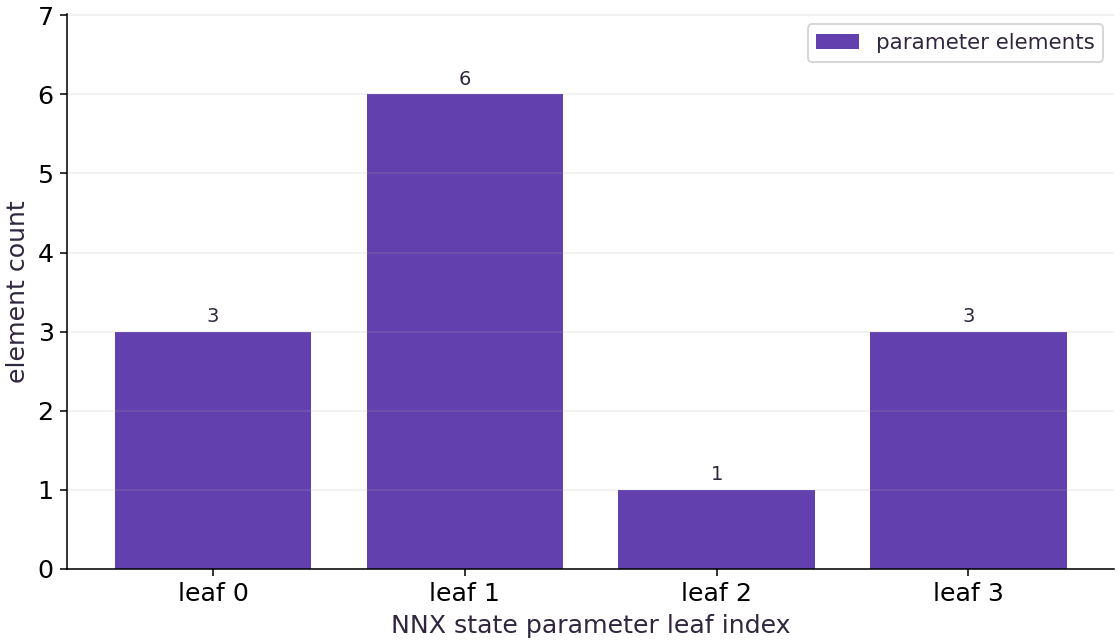

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each bar shows the exact element count of a parameter leaf extracted by `nnx.state(model, nnx.Param)`.

### Connect it to the computation

Splitting an NNX module into its graph definition and state PyTree makes every parameter leaf inspectable and transformable by standard JAX functions.

## Bias shifts every score equally

Predict: Adding $0.25$ to the output bias should do what to each logit?

In [7]:
# Experiment — Bias shifts every score equally: An affine output bias changes the decision threshold uniformly;...
before=np.asarray(model(batch))
# Compute `saved` from `model.out.bias[...]`
saved=model.out.bias[...]
# Compute `model.out.bias[...]` from `saved+.25`
model.out.bias[...] = saved+.25
# Compute `np.testing.assert_allclose(model(batch),before+.25,atol` as `1e-6)`.
np.testing.assert_allclose(model(batch),before+.25,atol=1e-6)
# Compute `model.out.bias[...]` from `saved`
model.out.bias[...] = saved

Expected: All logits increase by $0.25$.

An affine output bias changes the decision threshold uniformly; the hidden representation is unchanged.

## Repeated construction reproduces state

Predict: Will two modules initialized with the same seed produce equal parameters?

In [8]:
# Experiment — Repeated construction reproduces state: Replay is checked in one pinned environment.
replay=TinyMLP(0)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(jax.tree.leaves(nnx.state(replay,nnx.Param)),jax.tree.leaves(param_state)):
    # Execute `np.testing.assert_array_equal(a,b)`
    np.testing.assert_array_equal(a,b)
# Run `TinyMLP` to compute `different`.
different=TinyMLP(1)
# Assert that `not np.array_equal(np.asarray(different.hidden.kernel[...]),np.asarray(model.hidden.kernel[.`.
assert not np.array_equal(np.asarray(different.hidden.kernel[...]),np.asarray(model.hidden.kernel[...]))

Expected: Equal seeds reproduce the parameter arrays; a changed seed changes the hidden kernel.

Replay is checked in one pinned environment. Seeds alone do not promise identical bytes across package versions or backends.

## Your exercise

Apply the model to one new row and to five rows. Verify the scalar parameter count stays $13$ and the batch axis survives.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `nnx.Module / nnx.Linear / nnx.Optimizer` — Flax NNX stateful module and optimizer containers with explicit RNG streams (`nnx.Rngs`) and traced graph updates.

**Step-by-step implementation plan:**
1. Construct `single` via `jnp.array([[.3,-.7]])`
2. Check tensor shape invariant: `model(single).shape==(1,)`
3. Check tensor shape invariant: `model(jnp.repeat(single,5,axis=0)).shape==(5,)`
4. Assert invariant `sum(a.size for a in jax.tree.leaves(nnx.state(model,nnx.Param)))==13` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Apply the model to one new row and to five rows.
# Construct `single` via `jnp.array([[.3,-.7]])`
single = jnp.array(...)  # TODO: compute single
# Check tensor shape invariant: `model(single).shape==(1,)`
assert model(single).shape  # TODO: complete assertion check
# Check tensor shape invariant: `model(jnp.repeat(single,5,axis=0)).shape==(5,)`
assert model(jnp.repeat(single,5,axis=0)).shape  # TODO: complete assertion check
# Assert invariant `sum(a.size for a in jax.tree.leaves(nnx.state(model,nnx.Param)))==13` holds
assert sum(a.size for a  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Apply the model to one new row and to five rows.
# Construct `single` via `jnp.array([[.3,-.7]])`
# single = jnp.array(...)  # TODO: compute single
# Check tensor shape invariant: `model(single).shape==(1,)`
# assert model(single).shape  # TODO: complete assertion check
# Check tensor shape invariant: `model(jnp.repeat(single,5,axis=0)).shape==(5,)`
# assert model(jnp.repeat(single,5,axis=0)).shape  # TODO: complete assertion check
# Assert invariant `sum(a.size for a in jax.tree.leaves(nnx.state(model,nnx.Param)))==13` holds
# assert sum(a.size for a  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Apply the model to one new row and to five rows.
# Construct `single` via `jnp.array([[.3,-.7]])`
single=jnp.array([[.3,-.7]])
# Check tensor shape invariant: `model(single).shape==(1,)`
assert model(single).shape==(1,)
# Check tensor shape invariant: `model(jnp.repeat(single,5,axis=0)).shape==(5,)`
assert model(jnp.repeat(single,5,axis=0)).shape==(5,)
# Assert invariant `sum(a.size for a in jax.tree.leaves(nnx.state(model,nnx.Param)))==13` holds
assert sum(a.size for a in jax.tree.leaves(nnx.state(model,nnx.Param)))==13

## Change a clone without changing its source · Transfer

Increase only the cloned model’s output bias by one. Predict the change in every logit and verify the original model’s parameter leaves remain unchanged.

Hint: Snapshot the original parameters before editing clone.out.bias.

### How to write: Change a clone without changing its source — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `nnx.Module / nnx.Linear / nnx.Optimizer` — Flax NNX stateful module and optimizer containers with explicit RNG streams (`nnx.Rngs`) and traced graph updates.

**Step-by-step implementation plan:**
1. Transform every leaf of the parameter PyTree (`original_leaves`).
2. Convert `old_clone` to a host NumPy array for inspection or verification.
3. Compute `clone.out.bias[...]` from `clone.out.bias[...] + 1.`
4. Compute `np.testing.assert_allclose(clone(batch),old_clone+1.,rtol` as `1e-5,atol=1e-6)`.
5. Iterate over `(before, after)` to step through the computation:

**Starter code scaffold (fill in the TODOs):**

```python
# Change a clone without changing its source (Transfer): The bias is broadcast over observations, so every logit...
# Transform every leaf of the parameter PyTree (`original_leaves`).
original_leaves = ...  # TODO: compute original_leaves
# Convert `old_clone` to a host NumPy array for inspection or verification.
old_clone = np.asarray(...)  # TODO: compute old_clone
# Compute `clone.out.bias[...]` from `clone.out.bias[...] + 1.`
clone.out.bias[...] = ...  # TODO: compute clone.out.bias[...]
# Compute `np.testing.assert_allclose(clone(batch),old_clone+1.,rtol` as `1e-5,atol=1e-6)`.
np.testing.assert_allclose(clone(batch),old_clone+1.,rtol=1e-5,atol=1e-6)
# Iterate over `(before, after)` to step through the computation:
for before,after in zip(original_leaves,jax.tree.leaves(nnx.state(model,nnx.Param))):
    # Execute `np.testing.assert_array_equal(before,after)`
    np.testing.assert_array_equal(before,after)
# Print the observed values to compare against the expected result.
print('Clone logits shifted by one; original parameters unchanged.')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Change a clone without changing its source (Transfer): The bias is broadcast over observations, so every logit...
# Transform every leaf of the parameter PyTree (`original_leaves`).
# original_leaves = ...  # TODO: compute original_leaves
# Convert `old_clone` to a host NumPy array for inspection or verification.
# old_clone = np.asarray(...)  # TODO: compute old_clone
# Compute `clone.out.bias[...]` from `clone.out.bias[...] + 1.`
# clone.out.bias[...] = ...  # TODO: compute clone.out.bias[...]
# Compute `np.testing.assert_allclose(clone(batch),old_clone+1.,rtol` as `1e-5,atol=1e-6)`.
# np.testing.assert_allclose(clone(batch),old_clone+1.,rtol=1e-5,atol=1e-6)
# Iterate over `(before, after)` to step through the computation:
# for before,after in zip(original_leaves,jax.tree.leaves(nnx.state(model,nnx.Param))):
    # Execute `np.testing.assert_array_equal(before,after)`
#     np.testing.assert_array_equal(before,after)
# Print the observed values to compare against the expected result.
# print('Clone logits shifted by one; original parameters unchanged.')

## Reference reasoning

The bias is broadcast over observations, so every logit shifts equally. Comparing original leaves detects accidental aliasing; equal parameter counts cannot detect that bug.

In [12]:
# Change a clone without changing its source (Transfer): The bias is broadcast over observations, so every logit...
# Transform every leaf of the parameter PyTree (`original_leaves`).
original_leaves=[np.array(a,copy=True) for a in jax.tree.leaves(nnx.state(model,nnx.Param))]
# Convert `old_clone` to a host NumPy array for inspection or verification.
old_clone=np.asarray(clone(batch)).copy()
# Compute `clone.out.bias[...]` from `clone.out.bias[...] + 1.`
clone.out.bias[...] = clone.out.bias[...] + 1.
# Compute `np.testing.assert_allclose(clone(batch),old_clone+1.,rtol` as `1e-5,atol=1e-6)`.
np.testing.assert_allclose(clone(batch),old_clone+1.,rtol=1e-5,atol=1e-6)
# Iterate over `(before, after)` to step through the computation:
for before,after in zip(original_leaves,jax.tree.leaves(nnx.state(model,nnx.Param))):
    # Execute `np.testing.assert_array_equal(before,after)`
    np.testing.assert_array_equal(before,after)
# Print the observed values to compare against the expected result.
print('Clone logits shifted by one; original parameters unchanged.')

Clone logits shifted by one; original parameters unchanged.


## Diagnose a shared module reference · Intermediate

Assign `shared = model`, increment its counter, and demonstrate why this is not a snapshot. Then reconstruct an independent module.

Hint: Assignment changes which name refers to the same object.

### How to write: Diagnose a shared module reference — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jax.tree.map(lambda p, g: ..., params, grads)` — Applies a function leaf-by-leaf across matching PyTrees (such as updating every parameter tensor with its gradient).

**Step-by-step implementation plan:**
1. Diagnose a shared module reference (Intermediate): Sharing a graph is useful for tied layers but wrong for an...
2. Compute `shared` from `model`
3. Run `shared` to perform the next check or state transition.
4. Assert that `int(model.calls[...])==saved_count+1`.
5. Run `nnx.split` to compute `(graph, state)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Diagnose a shared module reference (Intermediate): Sharing a graph is useful for tied layers but wrong for an...
saved_count = int(...)  # TODO: compute saved_count
# Compute `shared` from `model`
shared = ...  # TODO: compute shared
# Run `shared` to perform the next check or state transition.
shared(batch,record = ...  # TODO: compute shared(batch,record
# Assert that `int(model.calls[...])==saved_count+1`.
assert int(model.calls[...])  # TODO: complete assertion check
# Run `nnx.split` to compute `(graph, state)`.
graph,state = nnx.split(...)  # TODO: compute graph,state
# Transform every leaf of the parameter PyTree (`independent`).
independent = nnx.merge(...)  # TODO: compute independent
# Run `independent` to perform the next check or state transition.
independent(batch,record = ...  # TODO: compute independent(batch,record
# Assert that `int(model.calls[...])==saved_count+1`.
assert int(model.calls[...])  # TODO: complete assertion check
# Assert that `int(independent.calls[...])==saved_count+2`.
assert int(independent.calls[...])  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Diagnose a shared module reference (Intermediate): Sharing a graph is useful for tied layers but wrong for an...
# saved_count = int(...)  # TODO: compute saved_count
# Compute `shared` from `model`
# shared = ...  # TODO: compute shared
# Run `shared` to perform the next check or state transition.
# shared(batch,record = ...  # TODO: compute shared(batch,record
# Assert that `int(model.calls[...])==saved_count+1`.
# assert int(model.calls[...])  # TODO: complete assertion check
# Run `nnx.split` to compute `(graph, state)`.
# graph,state = nnx.split(...)  # TODO: compute graph,state
# Transform every leaf of the parameter PyTree (`independent`).
# independent = nnx.merge(...)  # TODO: compute independent
# Run `independent` to perform the next check or state transition.
# independent(batch,record = ...  # TODO: compute independent(batch,record
# Assert that `int(model.calls[...])==saved_count+1`.
# assert int(model.calls[...])  # TODO: complete assertion check
# Assert that `int(independent.calls[...])==saved_count+2`.
# assert int(independent.calls[...])  # TODO: complete assertion check

## Reference reasoning

Sharing a graph is useful for tied layers but wrong for an independent evaluation copy. Split, copy state, and merge supply independent variables in this example.

In [14]:
# Diagnose a shared module reference (Intermediate): Sharing a graph is useful for tied layers but wrong for an...
saved_count=int(model.calls[...])
# Compute `shared` from `model`
shared=model
# Run `shared` to perform the next check or state transition.
shared(batch,record=True)
# Assert that `int(model.calls[...])==saved_count+1`.
assert int(model.calls[...])==saved_count+1
# Run `nnx.split` to compute `(graph, state)`.
graph,state=nnx.split(model)
# Transform every leaf of the parameter PyTree (`independent`).
independent=nnx.merge(graph,jax.tree.map(lambda a:jnp.array(a,copy=True),state))
# Run `independent` to perform the next check or state transition.
independent(batch,record=True)
# Assert that `int(model.calls[...])==saved_count+1`.
assert int(model.calls[...])==saved_count+1
# Assert that `int(independent.calls[...])==saved_count+2`.
assert int(independent.calls[...])==saved_count+2

## Checkpoint

What does excluding the counter from `nnx.Param` guarantee?

1. It is excluded from parameter gradients, but may still change in a forward pass
2. It can never change
3. It is automatically saved to disk

## Diagnose

If evaluation changes state, inspect every nonparameter variable and forward flag. If a clone changes the original, inspect shared references. If an NNX module fails under a raw JAX transform, use nnx transformations or split it into graph/state deliberately instead of hiding the error.

## Evidence

Keep the NumPy forward comparison, count of 13 trainable scalars and one diagnostic counter, counter independence after copying state, and logits for batch size one and five.

## Carry forward

- Move the explicit equations into a module
- Separate parameter state from diagnostic state
- Reconstruct an independent graph from a snapshot
- Check a library forward pass independently

## Primary references

- [Flax NNX basics](https://flax.readthedocs.io/en/latest/nnx_basics.html)
- [NNX module and pytree guide](https://flax.readthedocs.io/en/latest/guides/pytree.html)